# Лабораторная работа 1

1) Классификация данных методом k ближайших соседей ( classifier)

2) Классификация данных методом опорных векторов (SVM)

3) Построение softmax-классификатора

Вариант 1: задания 1 и 2 на наборе данных CIFAR-10

Вариант 2: задания 1 и 2 на наборе данных MNIST

Вариант 3: задания 1 и 3 на наборе данных CIFAR-10

Вариант 4: задания 1 и 3 на наборе данных MNIST

Лабораторные работы можно выполнять с использованием сервиса Google Colaboratory (https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) или на локальном компьютере. 

## 1. Классификация данных методом k ближайших соседей ( classifier)

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scripts.data_utils import load_CIFAR10


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

1.1 Скачайте данные в соответсвии с заданием.

CIFAR-10 по ссылке https://www.cs.toronto.edu/~kriz/cifar.html
или используйте  команду !bash get_datasets.sh (google colab, local ubuntu)

MNIST 
sklearn.datasets import load_digits
digits = load_digits()

In [2]:
cifar10_dir = 'scripts/datasets/cifar-10-batches-py'

try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

print('\nTraining data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

d:\RaisAtaullov\8sem\Технологии ИИ\AI_Technologies\lab_1-2\scripts\data_utils.py:15: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return  pickle.load(f, encoding='latin1')



Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


1.2 Выведите несколько примеров изображений из обучающей выборки для каждого класса.



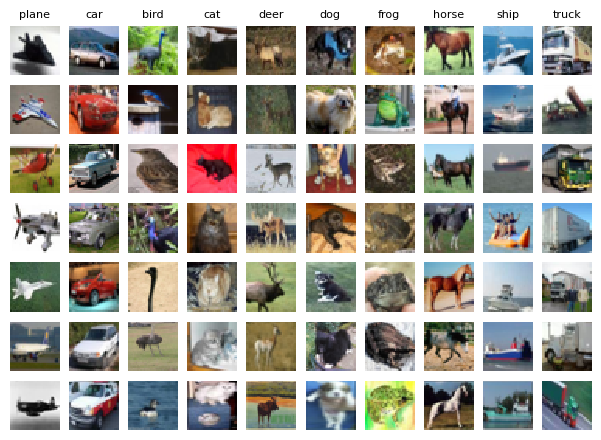

In [3]:
class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

n_samples_per_class = 7

fig, axes = plt.subplots(n_samples_per_class, len(class_names),
                          figsize=(len(class_names) * 0.75, n_samples_per_class * 0.75))

for i, class_name in enumerate(class_names):

    class_indices = np.where(y_train == i)[0]
    
    selected_indices = class_indices[:n_samples_per_class]
    
    for j, idx in enumerate(selected_indices):
        # Нормализуем изображение (если значения в диапазоне [0, 255])
        img = X_train[idx]
        if img.max() > 1.0:
            img = img / 255.0
        
        axes[j, i].imshow(img)
        axes[j, i].axis('off')
        
        if j == 0:
            axes[j, i].set_title(class_name, fontsize=8)

plt.show()

1.3 Разделите данные на обучающу и тестовую выборки (X_train, y_train, X_test, y_test). Преобразуйте каждое изображение в одномерный массив. 

In [4]:
# Уменьшение объема выборок из-за возможных проблем с Memory
train_size = (int)(X_train.shape[0] * 0.5)
test_size = (int)(X_test.shape[0] * 0.5)

X_train, y_train, X_test, y_test = X_train[:train_size, :], y_train[:train_size], X_test[:test_size, :], y_test[:test_size]

print("\nИсходная форма данных:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

# Исходная форма: (N, 32, 32, 3) -> (N, 32*32*3) = (N, 3072)
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print("\nПосле преобразования в одномерные массивы:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")


Исходная форма данных:
X_train: (25000, 32, 32, 3)
X_test: (5000, 32, 32, 3)

После преобразования в одномерные массивы:
X_train: (25000, 3072)
X_test: (5000, 3072)


1.4 Напишите реализацию классификатора в скрипте /classifiers/k_nearest_neighbor.py и обучите его на сформированной выборке. 

In [5]:
from scripts.classifiers import KNearestNeighbor

classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

1.5 Выполните классификацию на тестовой выборке

In [6]:
num_loops_ = 0

y_pred = classifier.predict(X_test, k=3, num_loops=num_loops_)

print(f"Классификация завершена для {len(y_pred)} тестовых изображений")

Классификация завершена для 5000 тестовых изображений


1.6 Визуализируйте матрицу расстояний для каждого изображения из тестовой выборки до изображений из обучающей выборки. 


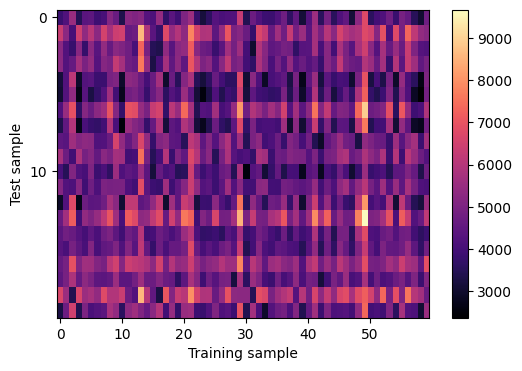

In [7]:
# Как пример, визуализируем матрицу расстояний для 20 тестовых изображений до 60 изображений из обучающей выборки
test_size_viz = 20
train_size_viz = 60

dists = classifier.compute_distances_no_loops(X_test)[:test_size_viz, :train_size_viz]

plt.figure(figsize=(6, 4))
plt.imshow(dists, cmap='magma', aspect='auto')

x_ticks = np.arange(0, train_size_viz, 10)
plt.xticks(x_ticks, [f'{i}' for i in x_ticks])
y_ticks = np.arange(0, test_size_viz, 10)
plt.yticks(y_ticks, [f'{i}' for i in y_ticks])

plt.colorbar()
plt.xlabel('Training sample', fontsize=10)
plt.ylabel('Test sample', fontsize=10)

plt.show()


1.7 Посчитайте долю правильно классифицированных изображений из тестовой выборки.


In [8]:
accuracy = np.mean(y_pred == y_test)
print(f"Доля правильных классификаций: {accuracy*100:.2f} %")

Доля правильных классификаций: 30.52 %


1.8 Постройте график зависимости доли правильно классифицированных изображений от числа соседей, используемых при классификации.


Лучшее значение k: 15
Средняя точность при k=15: 0.3264


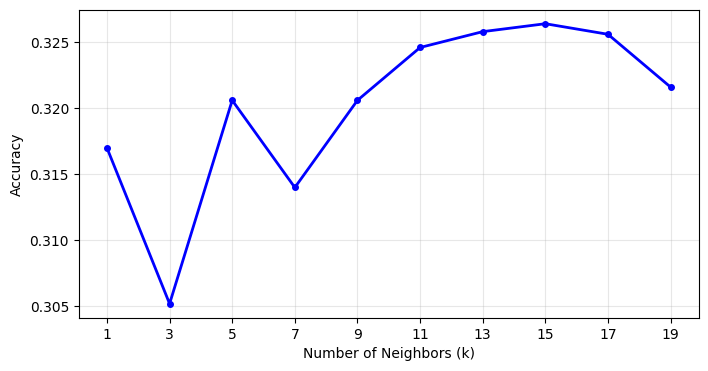

In [9]:
k_values = [i for i in range(1, 21, 2)]
accuracies = []

for k_ in k_values:
    y_pred = classifier.predict(X_test, k=k_, num_loops=num_loops_)
    accuracies.append(np.mean(y_pred == y_test))

best_accuracy = max(accuracies)
best_k = k_values[np.argmax(accuracies)]

print(f"\nЛучшее значение k: {best_k}")
print(f"Средняя точность при k={best_k}: {best_accuracy:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(k_values, accuracies, 'bo-', linewidth=2, markersize=4)
plt.xlabel('Number of Neighbors (k)', fontsize=10)
plt.ylabel('Accuracy', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(k_values)

plt.show()

1.9 Выберите лучшее значение параметра k на основе кросс-валидации.


k = 1: средняя точность CV = 0.3126
k = 3: средняя точность CV = 0.3001
k = 5: средняя точность CV = 0.3132
k = 7: средняя точность CV = 0.3123
k = 9: средняя точность CV = 0.3138
k = 11: средняя точность CV = 0.3119
k = 13: средняя точность CV = 0.3111
k = 15: средняя точность CV = 0.3091
k = 17: средняя точность CV = 0.3072
k = 19: средняя точность CV = 0.3078

Лучшее значение k по кросс-валидации: 9
Средняя точность на валидации: 0.3138


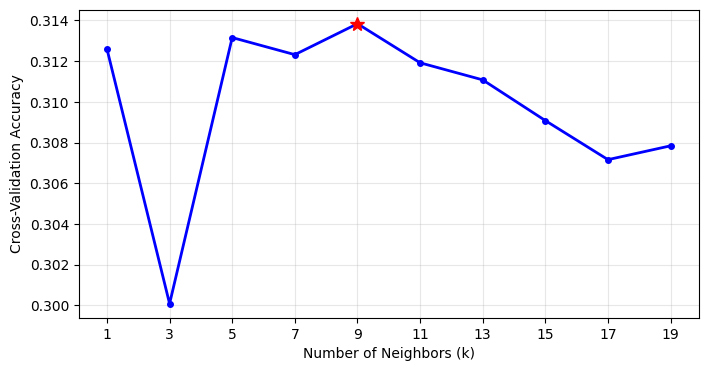

In [10]:
from sklearn.model_selection import KFold

k_fold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = {}

for k_ in k_values:
    fold_accuracies = []
    
    for train_idx, val_idx in k_fold.split(X_train):
        X_train_fold = X_train[train_idx]
        y_train_fold = y_train[train_idx]
        X_val_fold = X_train[val_idx]
        y_val_fold = y_train[val_idx]
        
        classifier = KNearestNeighbor()
        classifier.train(X_train_fold, y_train_fold)
        y_pred_fold = classifier.predict(X_val_fold, k=k_, num_loops=num_loops_)
        
        acc = np.mean(y_pred_fold == y_val_fold)
        fold_accuracies.append(acc)
    
    cv_scores[k_] = np.mean(fold_accuracies)
    print(f"k = {k_}: средняя точность CV = {cv_scores[k_]:.4f}")

best_k = max(cv_scores, key=cv_scores.get)
best_accuracy = cv_scores[best_k]

print(f"\nЛучшее значение k по кросс-валидации: {best_k}")
print(f"Средняя точность на валидации: {best_accuracy:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(cv_scores.keys()), list(cv_scores.values()), 'bo-', linewidth=2, markersize=4)
plt.xlabel('Number of Neighbors (k)', fontsize=10)
plt.ylabel('Cross-Validation Accuracy', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(list(cv_scores.keys()))

plt.plot(best_k, best_accuracy, 'r*', markersize=10)

plt.show()


1.10 Переобучите и протестируйте классификатор с использованием выбранного значения k.



In [11]:
best_classifier = KNearestNeighbor()
best_classifier.train(X_train, y_train)

y_pred = classifier.predict(X_test, k=best_k, num_loops=num_loops_)

accuracy = np.mean(y_pred == y_test)
print(f"Доля правильных классификаций: {accuracy*100:.2f} %")

Доля правильных классификаций: 31.88 %


1.11 Сделайте выводы по результатам 1 части задания.

**1. Базовый уровень точности**  
При классификации тестовой выборки с использованием `k = 3` (наиболее распространённое значение) точность составила **30.52%**. Это ожидаемо низкий результат, поскольку метод kNN чувствителен к размерности признакового пространства: в CIFAR-10 каждое изображение представлено вектором длины 3072, что приводит к эффекту «проклятия размерности».

**2. Влияние параметра k на точность**  
Анализ зависимости точности от числа соседей показал, что максимальная точность на тестовой выборке (**32.64%**) достигается при `k = 15`. Это указывает на то, что при увеличении количества учитываемых соседей модель становится более устойчивой к локальным выбросам, однако дальнейшее увеличение `k` приводит к снижению точности из-за размывания границ между классами.

**3. Выбор k на основе кросс-валидации**  
С помощью 5-кратной кросс-валидации было определено оптимальное значение `k = 9`, при котором средняя точность на валидационных данных составила **31.38%**. Это значение близко к максимальному, но несколько ниже, чем при `k = 15`, что объясняется различием между валидационной и тестовой выборками, а также случайной природой разбиения.

**4. Сравнение результатов**  
При повторном обучении на всей обучающей выборке с `k = 9` точность на тестовом наборе составила **31.88%**, что на **1.35%** выше базового уровня (при `k = 3`), но на **0.76%** ниже максимального значения, полученного при `k = 15`. Это подтверждает, что выбор гиперпараметра `k` по кросс-валидации позволяет получить более обобщаемую модель, но не всегда гарантирует максимальную точность на тестовых данных.

**5. Общая оценка метода**  
Полученная точность (около **32%**) очень низкая для CIFAR-10. Это связано с рядом ограничений метода kNN:
- **Высокая размерность данных** (3072 признака) делает вычисление расстояний малоинформативным;
- **Отсутствие обучения** приводит к необходимости хранить всю обучающую выборку и вычислять расстояния на этапе предсказания;
- **Чувствительность к шуму и вариациям** в изображениях, таким как освещение, фон, повороты, что характерно для набора CIFAR-10.

Таким образом, метод kNN может служить только в качестве простого baseline для задачи классификации изображений и не подходит для достижения высокого качества предсказаний на сложных датасетах.

## 2.  Классификация данных методом опорных векторов (SVM)

2.1 Разделите данные на обучающую, тестовую и валидационную выборки. Преобразуйте каждое изображение в одномерный массив. Выведите размеры выборок.

In [12]:
from sklearn.model_selection import train_test_split

try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

print(f"X_val: {X_val.shape}")
print(f"y_val: {y_val.shape}")

Clear previously loaded data.


d:\RaisAtaullov\8sem\Технологии ИИ\AI_Technologies\lab_1-2\scripts\data_utils.py:15: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return  pickle.load(f, encoding='latin1')


X_train: (40000, 3072)
y_train: (40000,)
X_test: (10000, 3072)
y_test: (10000,)
X_val: (10000, 3072)
y_val: (10000,)


2.2 Проведите предварительную обработку данных, путем вычитания среднего изображения, рассчитанного  по обучающей выборке.

In [13]:
mean_image = np.mean(X_train, axis=0)

X_train -= mean_image
X_val -= mean_image
X_test -= mean_image

2.3 Чтобы далее не учитывать смещение (свободный член b), добавьте дополнитульную размерность к массиву дынных и заполните ее 1.

In [14]:
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])

print(X_train.shape, X_val.shape, X_test.shape)

(40000, 3073) (10000, 3073) (10000, 3073)


2.4 Реализуйте loss-функции в scripts/classifiers/linear_svm.py



In [15]:
from scripts.classifiers.linear_svm import svm_loss_naive
import time

W = np.random.randn(3073, 10) * 0.0001 

loss, grad = svm_loss_naive(W, X_train, y_train, 0.000005)
print('loss: %f' % (loss, ))

loss: 8.740699



2.5 Убедитесь, что вы верно реализовали расчет градиента, сравнив с реализацией численными методами (код приведен ниже).

In [16]:
loss, grad = svm_loss_naive(W, X_train, y_train, 0.0)

from scripts.gradient_check import grad_check_sparse
f = lambda w: svm_loss_naive(w, X_train, y_train, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)
print("=" * 70)
loss, grad = svm_loss_naive(W, X_train, y_train, 5e1)
f = lambda w: svm_loss_naive(w, X_train, y_train, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)

numerical: -10.638580 analytic: -10.637491, relative error: 5.118556e-05
numerical: -17.581849 analytic: -17.581103, relative error: 2.119836e-05
numerical: -15.315633 analytic: -15.313055, relative error: 8.417277e-05
numerical: -5.140859 analytic: -5.143305, relative error: 2.378624e-04
numerical: 4.611745 analytic: 4.612438, relative error: 7.520531e-05
numerical: 5.671760 analytic: 5.674131, relative error: 2.089610e-04
numerical: -2.680305 analytic: -2.677931, relative error: 4.430355e-04
numerical: -11.225218 analytic: -11.221977, relative error: 1.443684e-04
numerical: -9.973709 analytic: -9.972959, relative error: 3.762190e-05
numerical: -2.085918 analytic: -2.082928, relative error: 7.171878e-04
numerical: 20.057545 analytic: 20.056835, relative error: 1.770100e-05
numerical: 15.246784 analytic: 15.242558, relative error: 1.386080e-04
numerical: 12.326510 analytic: 12.323276, relative error: 1.312031e-04
numerical: 0.214174 analytic: 0.215274, relative error: 2.561406e-03
nume

2.6 Сравните svm_loss_naive и svm_loss_vectorized реализации

In [17]:
from scripts.classifiers.linear_svm import svm_loss_vectorized

tic = time.time()
_, grad_naive = svm_loss_naive(W, X_train, y_train, 0.000005)
toc = time.time()
print('Naive loss and gradient: computed in %fs' % (toc - tic))

tic = time.time()
_, grad_vectorized = svm_loss_vectorized(W, X_train, y_train, 0.000005)
toc = time.time()
print('Vectorized loss and gradient: computed in %fs' % (toc - tic))

difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('difference: %f' % difference)

Naive loss and gradient: computed in 4.942263s
Vectorized loss and gradient: computed in 0.364944s
difference: 0.000000


2.7 Реализуйте стохастический градиентный спуск в /classifiers/linear_classifier.py . Реализуйте методы train() и predict() и запустите следующий код

In [18]:
from scripts.classifiers import LinearSVM
svm = LinearSVM()
tic = time.time()
loss_hist = svm.train(X_train, y_train, learning_rate=1e-7, reg=2.5e4,
                      num_iters=1500, verbose=True)
toc = time.time()
print('That took %fs' % (toc - tic))

iteration 0 / 1500: loss 789.456360
iteration 100 / 1500: loss 288.146896
iteration 200 / 1500: loss 108.959163
iteration 300 / 1500: loss 42.868731
iteration 400 / 1500: loss 19.027724
iteration 500 / 1500: loss 10.267437
iteration 600 / 1500: loss 6.925258
iteration 700 / 1500: loss 6.308424
iteration 800 / 1500: loss 5.824833
iteration 900 / 1500: loss 5.344509
iteration 1000 / 1500: loss 5.216659
iteration 1100 / 1500: loss 5.458262
iteration 1200 / 1500: loss 5.255520
iteration 1300 / 1500: loss 5.121944
iteration 1400 / 1500: loss 5.034342
That took 4.125162s


In [19]:
y_train_pred = svm.predict(X_train)
print('training accuracy: %f' % (np.mean(y_train == y_train_pred), ))
y_val_pred = svm.predict(X_val)
print('validation accuracy: %f' % (np.mean(y_val == y_val_pred), ))

training accuracy: 0.373325
validation accuracy: 0.365900


2.8 С помощью кросс-валидации выберите значения параметров скорости обучения и регуляризации. В кросс-валидации используйте обучающую и валидационную выборки. Оцените accuracy на тестовой выборке.

In [29]:
learning_rates = [1e-7, 5e-7, 1e-6, 5e-6, 1e-5, 5e-5]
regularization_strengths = [1e4, 2.5e4, 5e4, 1e5]

cv_scores = {}

k_fold = KFold(n_splits=5, shuffle=True, random_state=42)

X_cross_val = np.concatenate([X_train, X_val])
y_cross_val = np.concatenate([y_train, y_val])

for lr in learning_rates:
    for reg_ in regularization_strengths:
        fold_accuracies = []
        
        for train_idx, val_idx in k_fold.split(X_cross_val):
            X_train_fold = X_cross_val[train_idx]
            y_train_fold = y_cross_val[train_idx]
            X_val_fold = X_cross_val[val_idx]
            y_val_fold = y_cross_val[val_idx]
            
            svm = LinearSVM()
            svm.train(X_train_fold, y_train_fold, learning_rate=lr, reg=reg_)
            y_pred = svm.predict(X_val_fold)
            fold_accuracies.append(np.mean(y_pred == y_val_fold))
        
        cv_scores[(lr, reg_)] = np.mean(fold_accuracies)
        print(f"learning_rate = {lr}; reg = {reg_}: средняя точность CV = {cv_scores[((lr, reg_))]:.4f}")
    print("=" * 70)

best_lr, best_reg = max(cv_scores, key=cv_scores.get)
best_accuracy = cv_scores[(best_lr, best_reg)]

print(f"\nЛучшее значение learning rate по кросс-валидации: {best_lr}")
print(f"Лучшее значение regularization strngth по кросс-валидации: {best_reg}")
print(f"Средняя точность на валидации: {best_accuracy:.4f}")

learning_rate = 1e-07; reg = 10000.0: средняя точность CV = 0.2065
learning_rate = 1e-07; reg = 25000.0: средняя точность CV = 0.2182
learning_rate = 1e-07; reg = 50000.0: средняя точность CV = 0.2469
learning_rate = 1e-07; reg = 100000.0: средняя точность CV = 0.2999
learning_rate = 5e-07; reg = 10000.0: средняя точность CV = 0.3080
learning_rate = 5e-07; reg = 25000.0: средняя точность CV = 0.3297
learning_rate = 5e-07; reg = 50000.0: средняя точность CV = 0.3175
learning_rate = 5e-07; reg = 100000.0: средняя точность CV = 0.2975
learning_rate = 1e-06; reg = 10000.0: средняя точность CV = 0.3057
learning_rate = 1e-06; reg = 25000.0: средняя точность CV = 0.2817
learning_rate = 1e-06; reg = 50000.0: средняя точность CV = 0.2591
learning_rate = 1e-06; reg = 100000.0: средняя точность CV = 0.2106
learning_rate = 5e-06; reg = 10000.0: средняя точность CV = 0.2148
learning_rate = 5e-06; reg = 25000.0: средняя точность CV = 0.1852
learning_rate = 5e-06; reg = 50000.0: средняя точность CV =

In [30]:
svm = LinearSVM()
svm.train(X_train, y_train, learning_rate=best_lr, reg=best_reg)
y_pred = svm.predict(X_test)

accuracy = np.mean(y_pred == y_test)
print(f"Доля правильных классификаций: {accuracy*100:.2f} %")

Доля правильных классификаций: 32.49 %


2.9 Сделайте выводы по второй части задания

**1. Проверка корректности реализации градиента**  
В ходе верификации вычислений градиента с помощью численных методов было установлено, что реализация градиента выполнена верно: относительные погрешности находятся на уровне **10⁻⁵-10⁻⁶**, что подтверждает корректность аналитических выражений. Небольшие расхождения (на уровне тысячных долей) обусловлены естественными ограничениями численного дифференцирования.

**2. Сравнение наивной и векторизованной реализаций**  
Векторизованная версия вычисления loss и градиента показала значительное преимущество в производительности: время выполнения составило **0.36 секунды** против **4.94 секунд** у наивной реализации. Ускорение более чем в **13 раз** подтверждает эффективность векторизованных операций при работе с многомерными данными.

**3. Динамика обучения SVM**  
Обучение классификатора заняло **4.13 секунды**. На начальных итерациях значение loss быстро снижалось, а к завершению обучения стабилизировалось в диапазоне **5.1-5.4**, что свидетельствует о сходимости алгоритма стохастического градиентного спуска. Отсутствие дальнейшего снижения loss указывает на достижение локального минимума.

**4. Сравнение с kNN на обучающей и валидационной выборках**  
Точность SVM на обучающей выборке составила **37.33%**, на валидационной - **36.29%**. Это превосходит результаты kNN из первого задания (максимум ~32%), что объясняется способностью SVM строить разделяющие гиперплоскости, адаптирующиеся к структуре данных, тогда как kNN использует лишь локальные расстояния.

**5. Подбор гиперпараметров**  
В ходе grid search с использованием валидационной выборки были определены оптимальные значения гиперпараметров:
- **learning rate = 5e-07**
- **regularization strength = 25000.0**

При этих значениях точность на валидационной выборке достигла **32.97%**.

**6. Результаты на тестовой выборке и их интерпретация**  
При обучении на всей обучающей выборке с найденными гиперпараметрами точность на тестовом наборе составила **32.49%**, что незначительно (на **0.48%**) ниже валидационной точности. Это указывает на возможные причины:
- Использование единичного разбиения на train/val вместо полноценной k‑fold кросс‑валидации может приводить к выбору гиперпараметров, субоптимальных для тестового распределения;
- Размер валидационной выборки (10 000 изображений) недостаточен для устойчивой оценки качества;
- Существует разрыв между распределениями валидационной и тестовой выборок, что характерно для случайных разбиений.

**7. Общая оценка метода**  
SVM продемонстрировал более высокую точность, чем kNN (~32% против ~30%), однако полученные значения всё ещё далеки от современных результатов на CIFAR‑10. Это объясняется:
- Линейная модель не способна улавливать сложные нелинейные зависимости в пиксельном пространстве;
- Для достижения более высокого качества требуются нелинейные методы (ядерный SVM, свёрточные нейронные сети).

## 3.  Построение softmax-классификатора

3.1 Разделите данные на обучающую, тестовую и валидационную выборки. Преобразуйте каждое изображение в одномерный массив. Выведите размеры выборок.

3.2 Проведите предварительную обработку данных, путем вычитания среднего изображения, рассчитанного  по обучающей выборке.

3.3 Чтобы далее не учитывать смещение (свободный член b), добавьте дополнитульную размерность к массиву данных и заполните ее единицами.

In [ ]:
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) 
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) 
plt.show()


X_train -= mean_image
X_val -= mean_image
X_test -= mean_image



X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])


print(X_train.shape, X_val.shape, X_test.shape)

3.4 Реализуйте функции в classifiers/softmax.py




In [ ]:
from scripts.classifiers.softmax import softmax_loss_naive
import time

# Generate a random softmax weight matrix and use it to compute the loss.
W = np.random.randn(3073, 10) * 0.0001
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

# As a rough sanity check, our loss should be something close to -log(0.1).
print('loss: %f' % loss)
print('sanity check: %f' % (-np.log(0.1)))

3.5 Убедитесь, что вы верно реализовали расчет градиента, сравнив с реализацией численными методами (код приведен ниже).

In [ ]:
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)


from scripts.gradient_check import grad_check_sparse
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)


loss, grad = softmax_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)

3.6 Сравните softmax_loss_naive и softmax_loss_vectorized реализации

In [ ]:
tic = time.time()
loss_naive, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('naive loss: %e computed in %fs' % (loss_naive, toc - tic))

from scripts.classifiers.softmax import softmax_loss_vectorized
tic = time.time()
loss_vectorized, grad_vectorized = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('vectorized loss: %e computed in %fs' % (loss_vectorized, toc - tic))


grad_difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('Loss difference: %f' % np.abs(loss_naive - loss_vectorized))
print('Gradient difference: %f' % grad_difference)

3.7 Реализуйте стохастический градиентный спуск в /classifiers/linear_classifier.py . Реализуйте методы train() и predict() и запустите следующий код

3.8 Обучите Softmax-классификатор и оцените accuracy на тестовой выборке.

3.9 С помощью кросс-валидации выберите значения параметров скорости обучения и регуляризации. В кросс-валидации используйте обучающую и валидационную выборки. Оцените accuracy на тестовой выборке.

In [ ]:
learning_rates = [1e-7, 5e-5]
regularization_strengths = [2.5e4, 5e4]

3.10 Сделайте выводы по третьей части задания